# Система обнаружения стеганографии с помощью SRNet

**Архитектура:** Полный SRNet (Type-I + Type-II блоки с остаточными соединениями)  
**Данные:** RGB, 256×256, LSB-replacement, Cover=2000, Stego=2000  
**Оценка:** 5-Fold Stratified Cross-Validation  

Особенности реализации:
- HPF-слой (фильтр Кёнига 5×5, 3→64 канала), заморожен после 5 эпох
- 8 Type-I блоков без пулинга + 4 Type-II блока со stride=2
- BCEWithLogitsLoss + Adam + CosineAnnealingLR + gradient clipping
- Аугментации: HFlip, VFlip (без ротации — сохраняем LSB-сигнал)
- Нормализация: ToTensor() [0,1] без ImageNet-нормализации


In [1]:
# Монтирование Google Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
# 1. Импорт библиотек
import os
import json
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)


In [3]:
# 2. Воспроизводимость и проверка GPU
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')


Используемое устройство: cuda


In [4]:
# 3. Конфигурация данных

COVER_DIR = '/content/drive/MyDrive/FQW/Stego-Images_clean6000/'
STEGO_DIR = '/content/drive/MyDrive/FQW/Stego-Images_stego6000/'
IMG_SIZE = 256
MAX_IMAGES_PER_CLASS = 2000  # Cover=2000, Stego=2000

# Сбор путей к файлам (не грузим в память — экономия RAM)
cover_imgs = sorted([
    os.path.join(COVER_DIR, f) for f in os.listdir(COVER_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])[:MAX_IMAGES_PER_CLASS]

stego_imgs = sorted([
    os.path.join(STEGO_DIR, f) for f in os.listdir(STEGO_DIR)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
])[:MAX_IMAGES_PER_CLASS]

print(f'Загружено путей: Cover={len(cover_imgs)}, Stego={len(stego_imgs)}')

# Глобальные списки — используются в skf.split() на каждой итерации CV
images = cover_imgs + stego_imgs
labels = [0] * len(cover_imgs) + [1] * len(stego_imgs)

# Разбиение 80/20 для финального тест-сета
X_train, X_test, y_train, y_test = train_test_split(
    images, labels, test_size=0.2, random_state=SEED, stratify=labels
)
print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'Train: Cover={y_train.count(0)}, Stego={y_train.count(1)}')
print(f'Test:  Cover={y_test.count(0)},  Stego={y_test.count(1)}')


Загружено путей: Cover=2000, Stego=2000
Train: 3200, Test: 800
Train: Cover=1600, Stego=1600
Test:  Cover=400,  Stego=400


In [5]:
# 4. Dataset и DataLoader
class StegDataset(Dataset):
    def __init__(self, paths, labels, augment=False):
        self.paths   = paths
        self.labels  = labels
        self.augment = augment

        # Нормализация: только ToTensor() → [0, 1]
        self.base_transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),  # [0, 1]
        ])

        # Аугментации: только флипы — не изменяют значения пикселей
        self.train_transform = transforms.Compose([
            transforms.Resize((IMG_SIZE, IMG_SIZE)),
            transforms.ToTensor(),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.5),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')  # RGB — 3 канала
        if self.augment:
            img = self.train_transform(img)
        else:
            img = self.base_transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.float32)

# Предварительная проверка
test_ds = StegDataset(images[:4], labels[:4], augment=False)
x, y = test_ds[0]
print(f'Размер тензора: {x.shape}, dtype: {x.dtype}, диапазон: [{x.min():.3f}, {x.max():.3f}]')
print(f'Метка: {y}')


Размер тензора: torch.Size([3, 256, 256]), dtype: torch.float32, диапазон: [0.000, 0.957]
Метка: 0.0


In [6]:
# 5. Архитектура SRNet

# Структура:
#   HPF (3→64, kernel=5, frozen)      ← фильтр Кёнига для выделения шума
#   8× Type-I блоков (64 канала)      ← без пулинга, сохраняют разрешение
#   Type-II блок (64→128, stride=2)   ← 256×256 → 128×128
#   Type-II блок (128→256, stride=2)  ← 128×128 → 64×64
#   Type-II блок (256→512, stride=2)  ← 64×64   → 32×32
#   Type-II блок (512→512, stride=2)  ← 32×32   → 16×16
#   AdaptiveAvgPool2d(1) → Flatten
#   Dropout(0.3) → Linear(512, 1)

def init_king_weights_srnet(layer):
    """
    Инициализация HPF-слоя фильтром Кёнига (High-Pass Filter) 5×5.
    Адаптирован для 3 входных каналов RGB → 64 выходных фильтра.
    Веса замораживаются после нескольких первых эпох.
    """
    ker = np.array([
        [-1,  2, -2,  2, -1],
        [ 2, -6,  8, -6,  2],
        [-2,  8,-12,  8, -2],
        [ 2, -6,  8, -6,  2],
        [-1,  2, -2,  2, -1]
    ], dtype=np.float32)
    ker = ker / np.sum(np.abs(ker))

    out_channels = layer.out_channels  # 64
    in_channels  = layer.in_channels   # 3
    weight = np.zeros((out_channels, in_channels, 5, 5), dtype=np.float32)
    for i in range(out_channels):
        for c in range(in_channels):
            weight[i, c] = ker

    layer.weight.data = torch.from_numpy(weight).to(layer.weight.device)
    layer.weight.requires_grad = False  # Заморожен по умолчанию


class TypeIBlock(nn.Module):
    """
    Type-I блок SRNet: без пулинга, сохраняет пространственное разрешение.
    Обрабатывает изображение в исходном разрешении — критично для
    сохранения слабых LSB-следов без пространственных потерь.
    Схема: Conv→BN→ReLU→Conv→BN + residual → ReLU
    """
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + x)  # residual = Identity


class TypeIIBlock(nn.Module):
    """
    Type-II блок SRNet: уменьшает разрешение вдвое (stride=2).
    Shortcut использует Conv(1×1, stride=2) для согласования размерностей.
    Схема: Conv(stride=2)→BN→ReLU→Conv→BN + shortcut → ReLU
    """
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        # Shortcut: согласование каналов и разрешения
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=1, stride=2, bias=False),
            nn.BatchNorm2d(out_ch),
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.block(x) + self.shortcut(x))


class SRNet(nn.Module):
    """
    Полная архитектура SRNet для стеганоанализа RGB-изображений.
    Boroumand et al., 2019. Адаптирована для входа 3×256×256.
    Выход: логит (1 значение) для BCEWithLogitsLoss.
    """
    def __init__(self):
        super().__init__()

        # HPF-слой: выделяет шумовые остатки изображения
        # Инициализируется фильтром Кёнига, замораживается после warmup-эпох
        self.hpf = nn.Conv2d(3, 64, kernel_size=5, padding=2, bias=False)
        init_king_weights_srnet(self.hpf)

        self.hpf_bn = nn.BatchNorm2d(64)

        # 8 Type-I блоков: обрабатывают признаки в полном разрешении
        self.type1_blocks = nn.Sequential(*[TypeIBlock(64) for _ in range(8)])

        # 4 Type-II блока: последовательно уменьшают разрешение
        # 256→128→64→32→16
        self.type2_block1 = TypeIIBlock(64,  128)  # 256→128
        self.type2_block2 = TypeIIBlock(128, 256)  # 128→64
        self.type2_block3 = TypeIIBlock(256, 512)  # 64→32
        self.type2_block4 = TypeIIBlock(512, 512)  # 32→16

        # Классификатор
        self.gap     = nn.AdaptiveAvgPool2d(1)  # Global Average Pool → [B, 512, 1, 1]
        self.dropout = nn.Dropout(0.3)
        self.fc      = nn.Linear(512, 1)         # Логит для BCEWithLogitsLoss

        self._init_weights()

    def _init_weights(self):
        """Инициализация весов"""
        for m in self.modules():
            if isinstance(m, nn.Conv2d) and m is not self.hpf:
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        # HPF + BN (без нелинейности — сохраняем слабый остаточный сигнал)
        x = self.hpf_bn(self.hpf(x))

        # Type-I: 8 блоков в полном разрешении
        x = self.type1_blocks(x)

        # Type-II: постепенное уменьшение разрешения
        x = self.type2_block1(x)
        x = self.type2_block2(x)
        x = self.type2_block3(x)
        x = self.type2_block4(x)

        # Классификатор
        x = self.gap(x)                  # [B, 512, 1, 1]
        x = x.view(x.size(0), -1)        # [B, 512]
        x = self.dropout(x)
        return self.fc(x)                # [B, 1]


# Инициализация и проверка
model_test = SRNet().to(device)
total_params   = sum(p.numel() for p in model_test.parameters())
frozen_params  = sum(p.numel() for p in model_test.parameters() if not p.requires_grad)
print(f'Всего параметров:    {total_params:,}')
print(f'Заморожено (HPF):    {frozen_params:,}')
print(f'Обучаемых:           {total_params - frozen_params:,}')

# Проверка формы выхода
with torch.no_grad():
    dummy = torch.randn(2, 3, 256, 256).to(device)
    out   = model_test(dummy)
    print(f'Форма выхода: {out.shape}  (ожидается [2, 1])')
del model_test, dummy


Всего параметров:    10,403,393
Заморожено (HPF):    4,800
Обучаемых:           10,398,593
Форма выхода: torch.Size([2, 1])  (ожидается [2, 1])


In [7]:
# 6. Обучение: 5-Fold Cross-Validation SRNet

BATCH_SIZE             = 16
LEARNING_RATE          = 1e-3
EPOCHS                 = 25
UNFREEZE_EPOCHS_FOR_CV = 5
N_FOLDS                = 5

print('\n' + '='*60)
print(' ЗАПУСК 5-FOLD CROSS-VALIDATION для SRNet (TRAINING)')
print('='*60)
print(f'Датасет: {len(images)} изображений ({labels.count(0)} Cover + {labels.count(1)} Stego)')
print(f'Эпох на фолд: {EPOCHS} | Batch: {BATCH_SIZE} | LR: {LEARNING_RATE}')

# shuffle=True + random_state для воспроизводимости
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_metrics = {
    'auc':              [],
    'accuracy':         [],
    'precision_cover':  [],
    'precision_stego':  [],
    'recall_cover':     [],
    'recall_stego':     [],
    'f1_cover':         [],
    'f1_stego':         [],
}

all_fold_probs    = []
all_fold_labels   = []
all_fold_histories = []

for fold, (train_idx, val_idx) in enumerate(skf.split(images, labels)):
    print(f"\n{'='*60}")
    print(f" FOLD {fold+1}/{N_FOLDS}")
    print(f"{'='*60}")

    # Разбиение данных фолда
    X_train_fold = [images[i] for i in train_idx]
    y_train_fold = [labels[i] for i in train_idx]
    X_val_fold   = [images[i] for i in val_idx]
    y_val_fold   = [labels[i] for i in val_idx]

    print(f'Train: {len(X_train_fold)} | Val: {len(X_val_fold)}')
    print(f'Train баланс: Cover={y_train_fold.count(0)}, Stego={y_train_fold.count(1)}')
    print(f'Val баланс:   Cover={y_val_fold.count(0)},   Stego={y_val_fold.count(1)}')

    # DataLoaders фолда
    train_dataset_fold = StegDataset(X_train_fold, y_train_fold, augment=True)
    val_dataset_fold   = StegDataset(X_val_fold,   y_val_fold,   augment=False)

    train_loader_fold = DataLoader(
        train_dataset_fold, batch_size=BATCH_SIZE, shuffle=True,
        num_workers=2, pin_memory=True
    )
    val_loader_fold = DataLoader(
        val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=True
    )

    # Инициализация модели для фолда (каждый фолд — с нуля)
    model = SRNet().to(device)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    # CosineAnnealingLR: плавное снижение
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

    best_auc               = 0.0
    best_model_state       = None
    best_optimal_threshold = 0.5

    fold_history = {
        'loss': [], 'val_acc': [], 'val_prec': [],
        'val_rec': [], 'val_f1': [], 'val_auc': []
    }

    for epoch in range(EPOCHS):
        # Управление заморозкой HPF:
        # Первые UNFREEZE_EPOCHS_FOR_CV эпох — HPF адаптируется вместе с сетью,
        # затем замораживается, чтобы не деградировать инициализацию Кёнига.
        if epoch < UNFREEZE_EPOCHS_FOR_CV:
            model.hpf.weight.requires_grad = True
        else:
            model.hpf.weight.requires_grad = False

        # TRAIN
        model.train()
        running_loss = 0.0

        # batch_labels — локальная переменная батча
        for inputs, batch_labels in train_loader_fold:
            inputs       = inputs.to(device)
            batch_labels = batch_labels.to(device).unsqueeze(1).float()

            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, batch_labels)
            loss.backward()
            # Gradient clipping — стабилизирует обучение глубокой сети
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader_fold)
        scheduler.step()

        # VAL
        model.eval()
        all_val_labels_epoch = []
        all_val_probs_epoch  = []
        all_val_preds_epoch  = []

        with torch.no_grad():
            for inputs, batch_labels in val_loader_fold:
                inputs  = inputs.to(device)
                outputs = model(inputs)
                probs   = torch.sigmoid(outputs).cpu().numpy()
                preds   = (probs > 0.5).astype(int)

                all_val_probs_epoch.extend(probs)
                all_val_labels_epoch.extend(batch_labels.numpy())
                all_val_preds_epoch.extend(preds)

        # Метрики эпохи
        auc  = roc_auc_score(all_val_labels_epoch, all_val_probs_epoch)
        acc  = accuracy_score(all_val_labels_epoch, all_val_preds_epoch)
        prec = precision_score(all_val_labels_epoch, all_val_preds_epoch, zero_division=0)
        rec  = recall_score(all_val_labels_epoch, all_val_preds_epoch, zero_division=0)
        f1   = f1_score(all_val_labels_epoch, all_val_preds_epoch, zero_division=0)

        fold_history['loss'].append(avg_loss)
        fold_history['val_acc'].append(acc)
        fold_history['val_prec'].append(prec)
        fold_history['val_rec'].append(rec)
        fold_history['val_f1'].append(f1)
        fold_history['val_auc'].append(auc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            hpf_status = 'разморожен' if epoch < UNFREEZE_EPOCHS_FOR_CV else 'заморожен'
            print(f'  Epoch {epoch+1:2d}/{EPOCHS} | Loss: {avg_loss:.4f} | '
                  f'Acc: {acc:.4f} | F1: {f1:.4f} | AUC: {auc:.4f} | HPF: {hpf_status}')

        # Сохраняем лучшую модель по AUC
        if auc > best_auc:
            best_auc         = auc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            fpr_t, tpr_t, thr_t       = roc_curve(all_val_labels_epoch, all_val_probs_epoch)
            best_optimal_threshold    = thr_t[np.argmax(tpr_t - fpr_t)]

    # Финал фолда
    all_fold_histories.append(fold_history)

    all_val_labels_np = np.array(all_val_labels_epoch).flatten()
    all_val_probs_np  = np.array(all_val_probs_epoch).flatten()
    final_preds_fold  = (all_val_probs_np > best_optimal_threshold).astype(int)

    accuracy        = accuracy_score(all_val_labels_np, final_preds_fold)
    precision_cover = precision_score(all_val_labels_np, final_preds_fold, pos_label=0, zero_division=0)
    precision_stego = precision_score(all_val_labels_np, final_preds_fold, pos_label=1, zero_division=0)
    recall_cover    = recall_score(all_val_labels_np, final_preds_fold, pos_label=0, zero_division=0)
    recall_stego    = recall_score(all_val_labels_np, final_preds_fold, pos_label=1, zero_division=0)
    f1_cover        = f1_score(all_val_labels_np, final_preds_fold, pos_label=0, zero_division=0)
    f1_stego        = f1_score(all_val_labels_np, final_preds_fold, pos_label=1, zero_division=0)

    fold_metrics['auc'].append(best_auc)
    fold_metrics['accuracy'].append(accuracy)
    fold_metrics['precision_cover'].append(precision_cover)
    fold_metrics['precision_stego'].append(precision_stego)
    fold_metrics['recall_cover'].append(recall_cover)
    fold_metrics['recall_stego'].append(recall_stego)
    fold_metrics['f1_cover'].append(f1_cover)
    fold_metrics['f1_stego'].append(f1_stego)

    all_fold_probs.extend(all_val_probs_np.tolist())
    all_fold_labels.extend(all_val_labels_np.tolist())

    print(f'\n  Fold {fold+1} — лучшие результаты:')
    print(f'   AUC:      {best_auc:.4f}')
    print(f'   Accuracy: {accuracy:.4f}')
    print(f'   F1 Cover: {f1_cover:.4f} | F1 Stego: {f1_stego:.4f}')
    print(f'   Порог:    {best_optimal_threshold:.4f}')

    torch.save({
        'fold':             fold + 1,
        'model_state_dict': best_model_state,
        'best_auc':         float(best_auc),                 # float() — совместимость с weights_only=True
        'optimal_threshold': float(best_optimal_threshold),  # float() — совместимость с weights_only=True
        'fold_history':     fold_history,
    }, f'/content/srnet_fold_{fold+1}_model.pth')

# Сохранение промежуточных результатов
cv_results_training = {
    'n_folds':                 N_FOLDS,
    'unfreeze_epochs_per_fold': UNFREEZE_EPOCHS_FOR_CV,
    'model_architecture':      'SRNet (RGB 256x256, 8×TypeI + 4×TypeII)',
    'hyperparameters': {
        'batch_size':         BATCH_SIZE,
        'learning_rate':      LEARNING_RATE,
        'epochs_per_fold':    EPOCHS,
        'unfreeze_hpf_epochs': UNFREEZE_EPOCHS_FOR_CV,
        'scheduler':          'CosineAnnealingLR',
        'grad_clip':          1.0,
    },
    'fold_results': [
        {
            'fold':             i + 1,
            'auc':              float(fold_metrics['auc'][i]),
            'accuracy':         float(fold_metrics['accuracy'][i]),
            'f1_cover':         float(fold_metrics['f1_cover'][i]),
            'f1_stego':         float(fold_metrics['f1_stego'][i]),
            'precision_cover':  float(fold_metrics['precision_cover'][i]),
            'precision_stego':  float(fold_metrics['precision_stego'][i]),
            'recall_cover':     float(fold_metrics['recall_cover'][i]),
            'recall_stego':     float(fold_metrics['recall_stego'][i]),
            'optimal_threshold_at_best_auc': float(
                torch.load(f'/content/srnet_fold_{i+1}_model.pth', weights_only=False)['optimal_threshold']
            ),
        }
        for i in range(N_FOLDS)
    ],
    'aggregated_probs_and_labels': {
        'probs':  all_fold_probs,
        'labels': all_fold_labels,
    }
}

with open('/content/srnet_5fold_cv_training_results.json', 'w') as f:
    json.dump(cv_results_training, f, indent=2)

print(f'\nРезультаты сохранены: /content/srnet_5fold_cv_training_results.json')
print(f'Модели фолдов: /content/srnet_fold_1_model.pth ... srnet_fold_{N_FOLDS}_model.pth')



 ЗАПУСК 5-FOLD CROSS-VALIDATION для SRNet (TRAINING)
Датасет: 4000 изображений (2000 Cover + 2000 Stego)
Эпох на фолд: 25 | Batch: 16 | LR: 0.001

 FOLD 1/5
Train: 3200 | Val: 800
Train баланс: Cover=1600, Stego=1600
Val баланс:   Cover=400,   Stego=400
  Epoch  1/25 | Loss: 0.2850 | Acc: 0.5000 | F1: 0.6667 | AUC: 0.7415 | HPF: разморожен
  Epoch  5/25 | Loss: 0.0959 | Acc: 0.8650 | F1: 0.8612 | AUC: 0.9612 | HPF: разморожен
  Epoch 10/25 | Loss: 0.0821 | Acc: 0.5012 | F1: 0.0099 | AUC: 0.8454 | HPF: заморожен
  Epoch 15/25 | Loss: 0.0550 | Acc: 0.6863 | F1: 0.5445 | AUC: 0.9836 | HPF: заморожен
  Epoch 20/25 | Loss: 0.0323 | Acc: 0.9888 | F1: 0.9888 | AUC: 0.9965 | HPF: заморожен
  Epoch 25/25 | Loss: 0.0234 | Acc: 0.9862 | F1: 0.9864 | AUC: 0.9985 | HPF: заморожен

  Fold 1 — лучшие результаты:
   AUC:      0.9985
   Accuracy: 0.9912
   F1 Cover: 0.9912 | F1 Stego: 0.9913
   Порог:    0.7749

 FOLD 2/5
Train: 3200 | Val: 800
Train баланс: Cover=1600, Stego=1600
Val баланс:   Cover=


 АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ 5-FOLD CV — SRNet
AUC                   : 0.9988 ± 0.0013  [min=0.9964, max=0.9999]
ACCURACY              : 0.9305 ± 0.1191  [min=0.6925, max=0.9950]
F1_COVER              : 0.9032 ± 0.1737  [min=0.5560, max=0.9950]
F1_STEGO              : 0.9450 ± 0.0902  [min=0.7648, max=0.9950]
PRECISION_COVER       : 0.9925 ± 0.0082  [min=0.9777, max=1.0000]
PRECISION_STEGO       : 0.9154 ± 0.1482  [min=0.6192, max=0.9975]
RECALL_COVER          : 0.8685 ± 0.2418  [min=0.3850, max=0.9975]
RECALL_STEGO          : 0.9925 ± 0.0082  [min=0.9775, max=1.0000]

AUC на случайных лейблах (проверка утечки): 0.4936
(ожидается ~0.50; значительно выше → утечка данных)

Общий оптимальный порог (по всем фолдам): 0.9837

Classification Report (Aggregated, Optimal Threshold):
              precision    recall  f1-score   support

       Cover       0.97      0.90      0.93      2000
       Stego       0.91      0.97      0.94      2000

    accuracy                           0.94      400

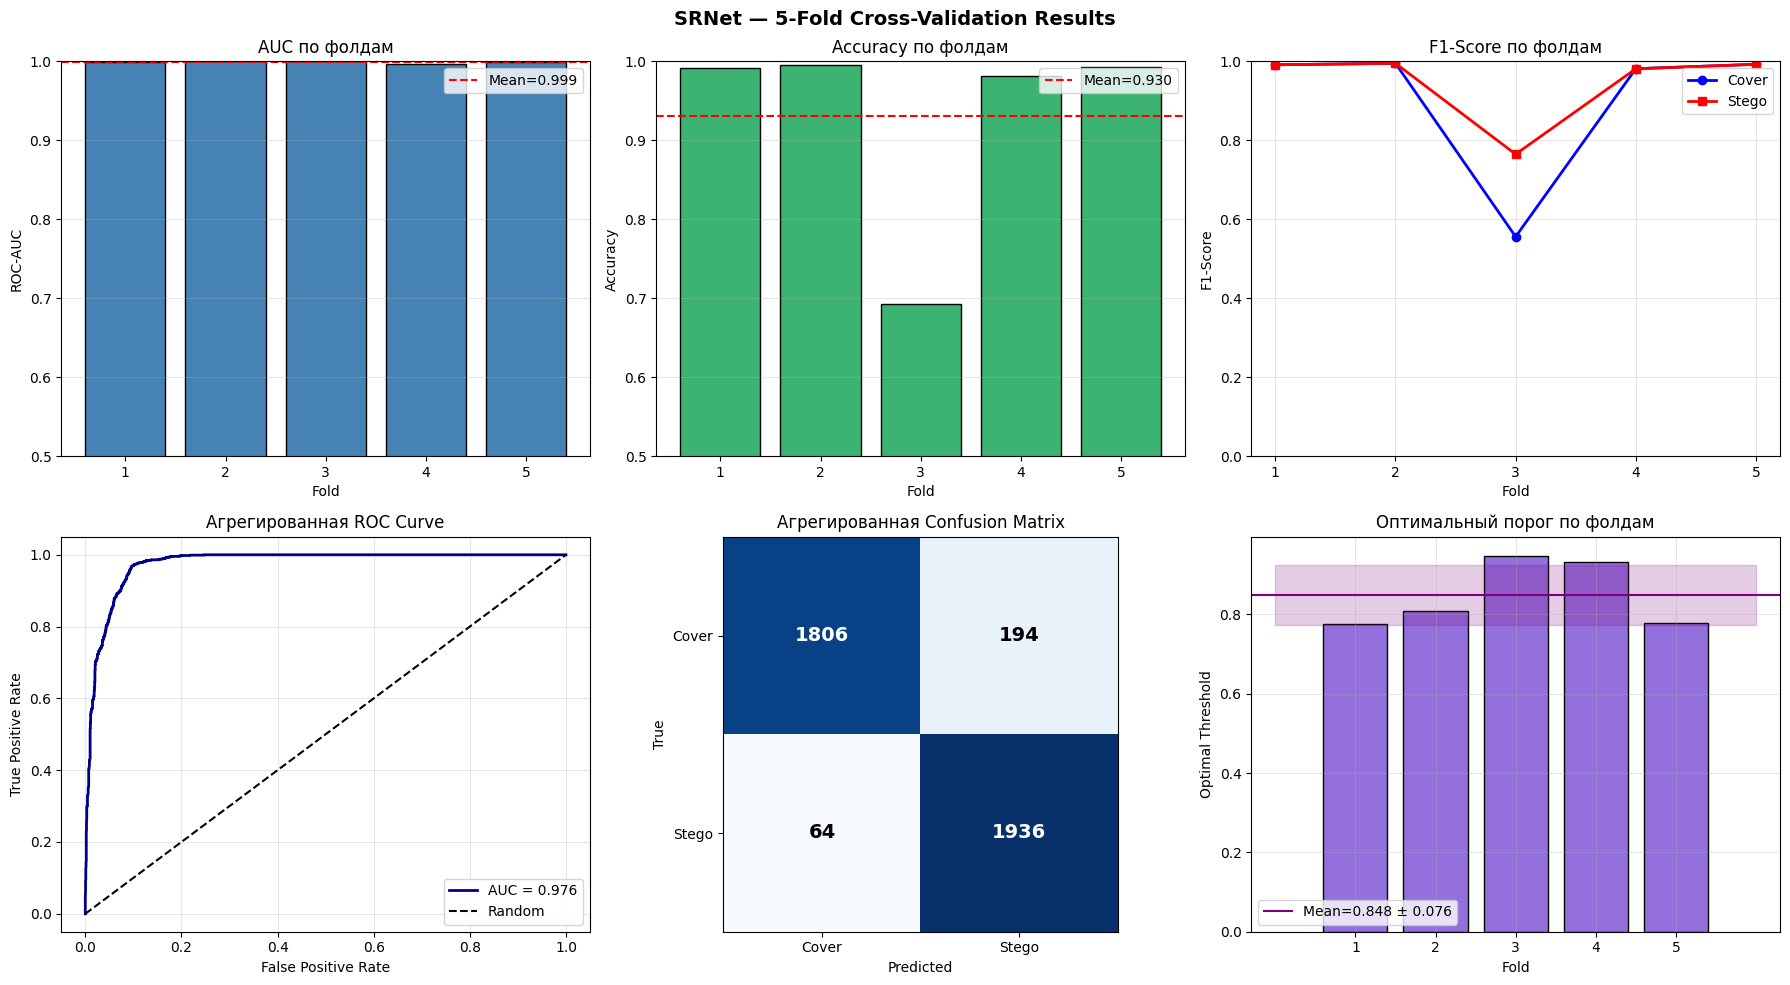


Финальные результаты сохранены: /content/srnet_5fold_cv_results.json
Графики сохранены:              /content/srnet_5fold_cv_results.png


In [8]:
# 7. Агрегация результатов и финальный отчёт

with open('/content/srnet_5fold_cv_training_results.json', 'r') as f:
    cv_results_training = json.load(f)

fold_metrics = {
    key: [res[key] for res in cv_results_training['fold_results']]
    for key in cv_results_training['fold_results'][0]
    if key not in ['fold', 'optimal_threshold_at_best_auc']
}
all_fold_probs  = cv_results_training['aggregated_probs_and_labels']['probs']
all_fold_labels = cv_results_training['aggregated_probs_and_labels']['labels']

print('\n' + '='*60)
print(' АГРЕГИРОВАННЫЕ РЕЗУЛЬТАТЫ 5-FOLD CV — SRNet')
print('='*60)

for metric_name in ['auc', 'accuracy', 'f1_cover', 'f1_stego',
                    'precision_cover', 'precision_stego',
                    'recall_cover', 'recall_stego']:
    values   = fold_metrics[metric_name]
    mean_val = np.mean(values)
    std_val  = np.std(values)
    min_val  = np.min(values)
    max_val  = np.max(values)
    print(f'{metric_name.upper():<22s}: {mean_val:.4f} ± {std_val:.4f}  '
          f'[min={min_val:.4f}, max={max_val:.4f}]')

# Проверка на утечку данных
all_fold_labels_np = np.array(all_fold_labels)
all_fold_probs_np  = np.array(all_fold_probs)
y_shuffled         = np.random.permutation(all_fold_labels_np)
auc_random         = roc_auc_score(y_shuffled, all_fold_probs_np)
print(f'\nAUC на случайных лейблах (проверка утечки): {auc_random:.4f}')
print(f'(ожидается ~0.50; значительно выше → утечка данных)')

# Оптимальный порог на агрегированных данных
fpr_agg, tpr_agg, thr_agg = roc_curve(all_fold_labels_np, all_fold_probs_np)
optimal_threshold_agg = thr_agg[np.argmax(tpr_agg - fpr_agg)]
final_preds_agg = (all_fold_probs_np > optimal_threshold_agg).astype(int)

print(f'\nОбщий оптимальный порог (по всем фолдам): {optimal_threshold_agg:.4f}')
print('\nClassification Report (Aggregated, Optimal Threshold):')
print(classification_report(
    all_fold_labels_np, final_preds_agg,
    target_names=['Cover', 'Stego'], zero_division=0
))

cm_agg = confusion_matrix(all_fold_labels_np, final_preds_agg)
print('Confusion Matrix (Aggregated):')
print(cm_agg)

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('SRNet — 5-Fold Cross-Validation Results', fontsize=14, fontweight='bold')

# 1. AUC по фолдам
axes[0, 0].bar(range(1, N_FOLDS+1), fold_metrics['auc'], color='steelblue', edgecolor='black')
axes[0, 0].axhline(y=np.mean(fold_metrics['auc']), color='red', linestyle='--',
                   label=f'Mean={np.mean(fold_metrics["auc"]):.3f}')
axes[0, 0].set_xlabel('Fold'); axes[0, 0].set_ylabel('ROC-AUC')
axes[0, 0].set_title('AUC по фолдам'); axes[0, 0].set_xticks(range(1, N_FOLDS+1))
axes[0, 0].legend(); axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].set_ylim([0.5, 1.0])

# 2. Accuracy по фолдам
axes[0, 1].bar(range(1, N_FOLDS+1), fold_metrics['accuracy'], color='mediumseagreen', edgecolor='black')
axes[0, 1].axhline(y=np.mean(fold_metrics['accuracy']), color='red', linestyle='--',
                   label=f'Mean={np.mean(fold_metrics["accuracy"]):.3f}')
axes[0, 1].set_xlabel('Fold'); axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy по фолдам'); axes[0, 1].set_xticks(range(1, N_FOLDS+1))
axes[0, 1].legend(); axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].set_ylim([0.5, 1.0])

# 3. F1-Score по фолдам
axes[0, 2].plot(range(1, N_FOLDS+1), fold_metrics['f1_cover'], 'b-o', label='Cover', linewidth=2)
axes[0, 2].plot(range(1, N_FOLDS+1), fold_metrics['f1_stego'], 'r-s', label='Stego', linewidth=2)
axes[0, 2].set_xlabel('Fold'); axes[0, 2].set_ylabel('F1-Score')
axes[0, 2].set_title('F1-Score по фолдам'); axes[0, 2].set_xticks(range(1, N_FOLDS+1))
axes[0, 2].legend(); axes[0, 2].grid(alpha=0.3)
axes[0, 2].set_ylim([0.0, 1.0])

# 4. Агрегированная ROC-кривая
fpr_final, tpr_final, _ = roc_curve(all_fold_labels_np, all_fold_probs_np)
overall_auc = roc_auc_score(all_fold_labels_np, all_fold_probs_np)
axes[1, 0].plot(fpr_final, tpr_final, color='darkblue', linewidth=2,
                label=f'AUC = {overall_auc:.3f}')
axes[1, 0].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1, 0].set_xlabel('False Positive Rate'); axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Агрегированная ROC Curve')
axes[1, 0].legend(); axes[1, 0].grid(alpha=0.3)

# 5. Confusion Matrix
axes[1, 1].imshow(cm_agg, interpolation='nearest', cmap='Blues')
axes[1, 1].set_title('Агрегированная Confusion Matrix')
axes[1, 1].set_xlabel('Predicted'); axes[1, 1].set_ylabel('True')
axes[1, 1].set_xticks([0, 1]); axes[1, 1].set_xticklabels(['Cover', 'Stego'])
axes[1, 1].set_yticks([0, 1]); axes[1, 1].set_yticklabels(['Cover', 'Stego'])
for i in range(2):
    for j in range(2):
        axes[1, 1].text(j, i, str(cm_agg[i, j]), ha='center', va='center',
                        fontsize=14, fontweight='bold',
                        color='white' if cm_agg[i, j] > cm_agg.max()/2 else 'black')

# 6. Оптимальные пороги по фолдам
thresholds_per_fold = [res['optimal_threshold_at_best_auc']
                       for res in cv_results_training['fold_results']]
mean_thresh = np.mean(thresholds_per_fold)
std_thresh  = np.std(thresholds_per_fold)
axes[1, 2].bar(range(1, N_FOLDS+1), thresholds_per_fold, color='mediumpurple', edgecolor='black')
axes[1, 2].axhline(y=mean_thresh, color='purple', linestyle='-',
                   label=f'Mean={mean_thresh:.3f} ± {std_thresh:.3f}')
axes[1, 2].fill_between(range(0, N_FOLDS+2),
                        mean_thresh - std_thresh, mean_thresh + std_thresh,
                        color='purple', alpha=0.2)
axes[1, 2].set_xlabel('Fold'); axes[1, 2].set_ylabel('Optimal Threshold')
axes[1, 2].set_title('Оптимальный порог по фолдам')
axes[1, 2].set_xticks(range(1, N_FOLDS+1))
axes[1, 2].legend(); axes[1, 2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/srnet_5fold_cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Сохранение финальных результатов
cv_results_final = {
    'n_folds':                 N_FOLDS,
    'unfreeze_epochs_per_fold': cv_results_training['unfreeze_epochs_per_fold'],
    'model_architecture':      cv_results_training['model_architecture'],
    'hyperparameters':         cv_results_training['hyperparameters'],
    'metrics': {
        'auc_mean':      float(np.mean(fold_metrics['auc'])),
        'auc_std':       float(np.std(fold_metrics['auc'])),
        'accuracy_mean': float(np.mean(fold_metrics['accuracy'])),
        'accuracy_std':  float(np.std(fold_metrics['accuracy'])),
        'f1_cover_mean': float(np.mean(fold_metrics['f1_cover'])),
        'f1_cover_std':  float(np.std(fold_metrics['f1_cover'])),
        'f1_stego_mean': float(np.mean(fold_metrics['f1_stego'])),
        'f1_stego_std':  float(np.std(fold_metrics['f1_stego'])),
    },
    'fold_details': cv_results_training['fold_results'],
    'aggregated': {
        'total_samples':           len(all_fold_labels_np),
        'overall_auc':             float(overall_auc),
        'overall_accuracy':        float(accuracy_score(all_fold_labels_np, final_preds_agg)),
        'overall_optimal_threshold': float(optimal_threshold_agg),
        'confusion_matrix':        cm_agg.tolist(),
    }
}

with open('/content/srnet_5fold_cv_results.json', 'w') as f:
    json.dump(cv_results_final, f, indent=2)

print(f'\nФинальные результаты сохранены: /content/srnet_5fold_cv_results.json')
print(f'Графики сохранены:              /content/srnet_5fold_cv_results.png')
